# Честное сравнение полноточного и тернарного трансформеров

Этот ноутбук сравнивает две **архитектурно одинаковые** decoder-only модели:

1. **Standard Transformer** — обычные `nn.Linear`;
2. **Ternary Transformer** — те же слои, но веса attention и FFN квантуются в \(\{-1,0,+1\}\) во время forward-pass с помощью straight-through estimator (STE).

Исправления относительно исходного эксперимента:

- обе модели используют одинаковый **каузальный** SDPA attention;
- модели отличаются только типом линейного слоя;
- тернарные веса масштабируются до округления и поэтому не обнуляются при инициализации;
- корпус делится на train/validation **до** объединения токенов;
- используются неперекрывающиеся блоки длины `sequence_length + 1`;
- обе модели получают одинаковую инициализацию и одинаковый порядок батчей;
- AMP и `torch.compile` включаются одинаково для обеих моделей;
- качество измеряется через validation loss, perplexity и token accuracy;
- скорость измеряется после прогрева и с синхронизацией CUDA;
- отдельно показываются фактический FP32-размер и теоретический размер packed ternary weights.

> Важно: тернарная модель ниже использует **fake quantization / QAT**. Без специализированного packed 2-bit CUDA/CPU kernel она не обязана работать быстрее стандартной модели. Бенчмарк измеряет реальное выполнение данного PyTorch-кода, а оценка packed size — потенциальный размер после отдельного экспорта.

## 1. Зависимости

Требуются Python 3.10+, PyTorch 2.x, `transformers`, `datasets`, `pandas`, `matplotlib` и `tqdm`.

При необходимости установите их отдельно, например:

```bash
pip install torch transformers datasets pandas matplotlib tqdm
```

In [1]:
import copy
import gc
import json
import math
import os
import random
import statistics
import time
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Callable, Optional, Type

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import DatasetDict, load_dataset
from torch.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
torch.set_float32_matmul_precision("high")

/home/phil/GitHub/llm/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
@dataclass
class ExperimentConfig:
    # Данные и токенизатор
    dataset_name: str = "intexcp/russian-llm-training-dataset"
    tokenizer_name: str = "deepvk/RuModernBERT-base"
    tokenizer_revision: Optional[str] = "patched-tokenizer"
    input_column: str = "input"
    output_column: str = "output"
    validation_fraction: float = 0.05
    max_train_records: Optional[int] = 100_000  # None = весь train
    max_validation_records: Optional[int] = 10_000  # None = весь validation
    tokenization_num_proc: int = min(8, os.cpu_count() or 1)
    tokenization_batch_size: int = 1_000
    max_text_tokens: int = 1_024

    # Модель
    sequence_length: int = 384
    d_model: int = 256
    n_heads: int = 4
    n_layers: int = 12
    d_ff: int = 1024
    dropout: float = 0.1
    tie_word_embeddings: bool = True

    # Обучение
    batch_size: int = 4
    num_workers: int = 0
    num_epochs: int = 5
    max_train_steps: Optional[int] = 4_000
    learning_rate: float = 2e-4
    weight_decay: float = 0.1
    warmup_ratio: float = 0.05
    grad_clip_norm: float = 1.0
    gradient_accumulation_steps: int = 2
    eval_every_steps: int = 200
    max_eval_batches: Optional[int] = 200
    log_every_steps: int = 25

    # Исполнение
    seed: int = 42
    use_amp: bool = True
    use_torch_compile: bool = True
    compile_mode: str = "default"

    # Бенчмарк
    benchmark_warmup: int = 20
    benchmark_repeats: int = 100

    # Выходные файлы
    output_dir: str = "transformer_benchmark_outputs"


cfg = ExperimentConfig()
print(json.dumps(asdict(cfg), ensure_ascii=False, indent=2))

{
  "dataset_name": "intexcp/russian-llm-training-dataset",
  "tokenizer_name": "deepvk/RuModernBERT-base",
  "tokenizer_revision": "patched-tokenizer",
  "input_column": "input",
  "output_column": "output",
  "validation_fraction": 0.05,
  "max_train_records": 100000,
  "max_validation_records": 10000,
  "tokenization_num_proc": 8,
  "tokenization_batch_size": 1000,
  "max_text_tokens": 1024,
  "sequence_length": 384,
  "d_model": 256,
  "n_heads": 4,
  "n_layers": 12,
  "d_ff": 1024,
  "dropout": 0.1,
  "tie_word_embeddings": true,
  "batch_size": 4,
  "num_workers": 0,
  "num_epochs": 5,
  "max_train_steps": 5000,
  "learning_rate": 0.0002,
  "weight_decay": 0.1,
  "warmup_ratio": 0.05,
  "grad_clip_norm": 1.0,
  "gradient_accumulation_steps": 2,
  "eval_every_steps": 200,
  "max_eval_batches": 200,
  "log_every_steps": 25,
  "seed": 42,
  "use_amp": true,
  "use_torch_compile": true,
  "compile_mode": "default",
  "benchmark_warmup": 20,
  "benchmark_repeats": 100,
  "output_dir":

## 2. Воспроизводимость и диагностика устройства

In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def select_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


seed_everything(cfg.seed)
device = select_device()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

print(f"PyTorch: {torch.__version__}")
print(f"Устройство: {device}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA runtime: {torch.version.cuda}")
    print(f"BF16 поддерживается: {torch.cuda.is_bf16_supported()}")
else:
    print("CUDA не используется. Скоростной бенчмарк будет отражать CPU/MPS, а не GPU.")

PyTorch: 2.13.0+cu130
Устройство: cuda
CUDA доступна: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA runtime: 13.0
BF16 поддерживается: True


## 3. Загрузка и разделение датасета

Разделение выполняется на уровне исходных записей, чтобы train и validation не содержали соседние фрагменты одного общего потока токенов.

In [4]:
raw = load_dataset(cfg.dataset_name)
print(raw)

if "train" not in raw:
    raise KeyError("В датасете отсутствует split 'train'.")

required_columns = {cfg.input_column, cfg.output_column}
missing_columns = required_columns - set(raw["train"].column_names)
if missing_columns:
    raise KeyError(
        f"В train отсутствуют колонки {sorted(missing_columns)}. "
        f"Доступны: {raw['train'].column_names}"
    )

if "validation" in raw:
    train_raw = raw["train"]
    validation_raw = raw["validation"]
elif "test" in raw:
    train_raw = raw["train"]
    validation_raw = raw["test"]
else:
    split = raw["train"].train_test_split(
        test_size=cfg.validation_fraction,
        seed=cfg.seed,
        shuffle=True,
    )
    train_raw = split["train"]
    validation_raw = split["test"]

if cfg.max_train_records is not None:
    train_raw = train_raw.select(range(min(cfg.max_train_records, len(train_raw))))
if cfg.max_validation_records is not None:
    validation_raw = validation_raw.select(
        range(min(cfg.max_validation_records, len(validation_raw)))
    )

print(f"Train-записей: {len(train_raw):,}")
print(f"Validation-записей: {len(validation_raw):,}")

DatasetDict({
    train: Dataset({
        features: ['input', 'think', 'output'],
        num_rows: 345889
    })
    test: Dataset({
        features: ['input', 'think', 'output'],
        num_rows: 3494
    })
})
Train-записей: 100,000
Validation-записей: 3,494


## 4. Токенизатор

`RuModernBERT` является encoder-токенизатором, но его словарь можно использовать для небольшого decoder-only эксперимента. Если отдельного EOS-токена нет, в качестве EOS используется `SEP`; при отсутствии обоих добавляется новый токен.

In [5]:
tokenizer_kwargs = {}
if cfg.tokenizer_revision is not None:
    tokenizer_kwargs["revision"] = cfg.tokenizer_revision

try:
    tokenizer = AutoTokenizer.from_pretrained(
        cfg.tokenizer_name,
        **tokenizer_kwargs,
    )
except Exception as exc:
    if cfg.tokenizer_revision is None:
        raise
    print(
        f"Не удалось загрузить revision={cfg.tokenizer_revision!r}: {exc}\n"
        "Повторная загрузка без указания revision."
    )
    tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_name)

if tokenizer.eos_token_id is None:
    if tokenizer.sep_token_id is not None:
        tokenizer.eos_token = tokenizer.sep_token
    else:
        tokenizer.add_special_tokens({"eos_token": "<|eos|>"})

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

vocab_size = len(tokenizer)
print(f"Размер словаря: {vocab_size:,}")
print(f"EOS: {tokenizer.eos_token!r}, id={tokenizer.eos_token_id}")
print(f"PAD: {tokenizer.pad_token!r}, id={tokenizer.pad_token_id}")

Размер словаря: 50,368
EOS: '[SEP]', id=50282
PAD: '[PAD]', id=50283


## 5. Токенизация и формирование неперекрывающихся LM-блоков

Каждый блок содержит `sequence_length + 1` токен. Первые `sequence_length` токенов становятся входом, последние — сдвинутой на один токен целью.

В отличие от исходного `TokenDataset`, соседние примеры здесь не перекрываются на 127 из 128 токенов.

In [6]:
def format_examples(examples: dict) -> dict:
    texts = []
    eos = tokenizer.eos_token or ""

    for prompt, answer in zip(
        examples[cfg.input_column],
        examples[cfg.output_column],
    ):
        prompt = "" if prompt is None else str(prompt)
        answer = "" if answer is None else str(answer)
        texts.append(
            f"Вопрос:\n{prompt}\n\nОтвет:\n{answer}{eos}"
        )

    encoded = tokenizer(
        texts,
        add_special_tokens=False,
        truncation=True,
        max_length=cfg.max_text_tokens,
        padding=False,
        return_attention_mask=False,
    )
    return {"input_ids": encoded["input_ids"]}


def group_into_causal_blocks(examples: dict) -> dict:
    block_with_target = cfg.sequence_length + 1
    concatenated = []
    for token_ids in examples["input_ids"]:
        concatenated.extend(token_ids)

    usable_length = (len(concatenated) // block_with_target) * block_with_target
    concatenated = concatenated[:usable_length]

    blocks = [
        concatenated[start:start + block_with_target]
        for start in range(0, usable_length, block_with_target)
    ]

    return {
        "input_ids": [block[:-1] for block in blocks],
        "labels": [block[1:] for block in blocks],
    }


def prepare_split(dataset, split_name: str):
    tokenized = dataset.map(
        format_examples,
        batched=True,
        batch_size=cfg.tokenization_batch_size,
        num_proc=cfg.tokenization_num_proc,
        remove_columns=dataset.column_names,
        desc=f"Токенизация {split_name}",
    )

    grouped = tokenized.map(
        group_into_causal_blocks,
        batched=True,
        batch_size=cfg.tokenization_batch_size,
        num_proc=1,
        remove_columns=tokenized.column_names,
        desc=f"Формирование блоков {split_name}",
    )
    grouped.set_format(type="torch", columns=["input_ids", "labels"])
    return grouped


train_dataset = prepare_split(train_raw, "train")
validation_dataset = prepare_split(validation_raw, "validation")

if len(train_dataset) == 0 or len(validation_dataset) == 0:
    raise RuntimeError(
        "После группировки получился пустой split. Увеличьте число записей "
        "или уменьшите sequence_length."
    )

print(f"Train-блоков: {len(train_dataset):,}")
print(f"Validation-блоков: {len(validation_dataset):,}")
print(f"Форма одного входа: {tuple(train_dataset[0]['input_ids'].shape)}")

Формирование блоков validation (num_proc=1): 100%|██████████| 3494/3494 [00:00<00:00, 4073.63 examples/s]

Train-блоков: 158,391
Validation-блоков: 5,532
Форма одного входа: (384,)


In [7]:
def make_dataloaders(seed: int) -> tuple[DataLoader, DataLoader]:
    generator = torch.Generator()
    generator.manual_seed(seed)

    common_kwargs = {
        "batch_size": cfg.batch_size,
        "num_workers": cfg.num_workers,
        "pin_memory": device.type == "cuda",
        "persistent_workers": cfg.num_workers > 0,
    }

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        drop_last=True,
        generator=generator,
        **common_kwargs,
    )
    validation_loader = DataLoader(
        validation_dataset,
        shuffle=False,
        drop_last=False,
        **common_kwargs,
    )
    return train_loader, validation_loader


train_loader_check, validation_loader_check = make_dataloaders(cfg.seed)
first_batch = next(iter(train_loader_check))
print({key: tuple(value.shape) for key, value in first_batch.items()})

{'input_ids': (4, 384), 'labels': (4, 384)}


## 6. Тернарный линейный слой

Для каждой выходной строки весов вычисляется масштаб

\[
\alpha_i = \operatorname{mean}_j |W_{ij}|.
\]

Затем мастер-веса квантуются как

\[
Q(W_{ij}) = \operatorname{clip}\!\left(\operatorname{round}\left(\frac{W_{ij}}{\alpha_i}\right), -1, 1\right)\alpha_i.
\]

В backward-pass используется straight-through estimator:

```python
W_q = W + (Q(W) - W).detach()
```

Поэтому оптимизатор обновляет полноточные мастер-веса, а forward использует их тернарное приближение.

In [8]:
def ternary_quantize_per_output_channel(
    weight: torch.Tensor,
    eps: float = 1e-5,
) -> tuple[torch.Tensor, torch.Tensor]:
    scale = weight.detach().abs().mean(dim=1, keepdim=True).clamp_min(eps)
    ternary_codes = torch.clamp(torch.round(weight / scale), min=-1, max=1)
    quantized_weight = ternary_codes * scale
    return quantized_weight, ternary_codes


class TernaryLinear(nn.Linear):
    """Weight-only ternary fake quantization with per-output-channel scale."""

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        quantized, _ = ternary_quantize_per_output_channel(self.weight)
        ste_weight = self.weight + (quantized - self.weight).detach()
        return F.linear(x, ste_weight, self.bias)

## 7. Единая архитектура decoder-only трансформера

Обе модели используют один и тот же код attention, residual connections, LayerNorm, FFN, позиционные embedding и LM-head. Единственное отличие — `nn.Linear` против `TernaryLinear` внутри attention и FFN.

In [9]:
@dataclass
class ModelConfig:
    vocab_size: int
    max_seq_len: int
    d_model: int
    n_heads: int
    n_layers: int
    d_ff: int
    dropout: float
    tie_word_embeddings: bool = True


class CausalSelfAttention(nn.Module):
    def __init__(
        self,
        model_cfg: ModelConfig,
        linear_cls: Type[nn.Linear],
    ) -> None:
        super().__init__()
        if model_cfg.d_model % model_cfg.n_heads != 0:
            raise ValueError("d_model должен делиться на n_heads без остатка")

        self.n_heads = model_cfg.n_heads
        self.head_dim = model_cfg.d_model // model_cfg.n_heads
        self.dropout = model_cfg.dropout

        self.q_proj = linear_cls(model_cfg.d_model, model_cfg.d_model, bias=False)
        self.k_proj = linear_cls(model_cfg.d_model, model_cfg.d_model, bias=False)
        self.v_proj = linear_cls(model_cfg.d_model, model_cfg.d_model, bias=False)
        self.out_proj = linear_cls(model_cfg.d_model, model_cfg.d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, d_model = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        attention = F.scaled_dot_product_attention(
            q,
            k,
            v,
            attn_mask=None,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=True,
        )

        attention = attention.transpose(1, 2).contiguous().view(
            batch_size,
            seq_len,
            d_model,
        )
        return self.out_proj(attention)


class DecoderBlock(nn.Module):
    def __init__(
        self,
        model_cfg: ModelConfig,
        linear_cls: Type[nn.Linear],
    ) -> None:
        super().__init__()
        self.ln_attn = nn.LayerNorm(model_cfg.d_model)
        self.attn = CausalSelfAttention(model_cfg, linear_cls)
        self.ln_ffn = nn.LayerNorm(model_cfg.d_model)
        self.ffn = nn.Sequential(
            linear_cls(model_cfg.d_model, model_cfg.d_ff, bias=False),
            nn.GELU(),
            linear_cls(model_cfg.d_ff, model_cfg.d_model, bias=False),
            nn.Dropout(model_cfg.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln_attn(x))
        x = x + self.ffn(self.ln_ffn(x))
        return x


class DecoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        model_cfg: ModelConfig,
        linear_cls: Type[nn.Linear] = nn.Linear,
    ) -> None:
        super().__init__()
        self.config = model_cfg
        self.token_embedding = nn.Embedding(model_cfg.vocab_size, model_cfg.d_model)
        self.position_embedding = nn.Embedding(model_cfg.max_seq_len, model_cfg.d_model)
        self.embedding_dropout = nn.Dropout(model_cfg.dropout)

        self.blocks = nn.ModuleList(
            DecoderBlock(model_cfg, linear_cls)
            for _ in range(model_cfg.n_layers)
        )
        self.final_norm = nn.LayerNorm(model_cfg.d_model)
        self.lm_head = nn.Linear(model_cfg.d_model, model_cfg.vocab_size, bias=False)

        self.apply(self._initialize_weights)

        if model_cfg.tie_word_embeddings:
            self.lm_head.weight = self.token_embedding.weight

    @staticmethod
    def _initialize_weights(module: nn.Module) -> None:
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = input_ids.shape
        if seq_len > self.config.max_seq_len:
            raise ValueError(
                f"Длина {seq_len} превышает max_seq_len={self.config.max_seq_len}"
            )

        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
        x = self.token_embedding(input_ids) + self.position_embedding(positions)
        x = self.embedding_dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.final_norm(x)
        return self.lm_head(x)

## 8. Создание моделей с одинаковой инициализацией

In [ ]:
model_cfg = ModelConfig(
    vocab_size=vocab_size,
    max_seq_len=cfg.sequence_length,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    n_layers=cfg.n_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
    tie_word_embeddings=cfg.tie_word_embeddings,
)


def build_model(linear_cls: Type[nn.Linear]) -> DecoderOnlyTransformer:
    # Один и тот же seed перед созданием каждой модели обеспечивает
    # одинаковые исходные полноточные мастер-веса.
    seed_everything(cfg.seed)
    return DecoderOnlyTransformer(model_cfg, linear_cls=linear_cls)


standard_model = build_model(nn.Linear)
ternary_model = build_model(TernaryLinear)

standard_state = standard_model.state_dict()
ternary_state = ternary_model.state_dict()
common_keys = standard_state.keys() & ternary_state.keys()
initialization_matches = all(
    torch.equal(standard_state[key], ternary_state[key])
    for key in common_keys
)

print(f"Одинаковая инициализация общих параметров: {initialization_matches}")
print(f"Standard parameters: {sum(p.numel() for p in standard_model.parameters()):,}")
print(f"Ternary parameters:  {sum(p.numel() for p in ternary_model.parameters()):,}")

if not initialization_matches:
    raise RuntimeError("Начальные веса моделей не совпадают.")

Одинаковая инициализация общих параметров: True
Standard parameters: 22,442,496
Ternary parameters:  22,442,496


In [11]:
@torch.no_grad()
def ternary_code_statistics(model: nn.Module) -> pd.DataFrame:
    rows = []
    for name, module in model.named_modules():
        if not isinstance(module, TernaryLinear):
            continue

        _, codes = ternary_quantize_per_output_channel(module.weight)
        total = codes.numel()
        rows.append(
            {
                "layer": name,
                "weights": total,
                "-1_%": 100.0 * (codes == -1).sum().item() / total,
                "0_%": 100.0 * (codes == 0).sum().item() / total,
                "+1_%": 100.0 * (codes == 1).sum().item() / total,
            }
        )
    return pd.DataFrame(rows)


initial_ternary_stats = ternary_code_statistics(ternary_model)
display(initial_ternary_stats)

if not initial_ternary_stats.empty and initial_ternary_stats["0_%"].eq(100.0).all():
    raise RuntimeError("Все тернарные веса обнулились — квантизация настроена неверно.")

,layer,weights,-1_%,0_%,+1_%
0,blocks.0.attn.q_proj,65536,34.495544,30.799866,34.704590
1,blocks.0.attn.k_proj,65536,34.538269,30.912781,34.548950
2,blocks.0.attn.v_proj,65536,34.333801,31.047058,34.619141
3,blocks.0.attn.out_proj,65536,34.715271,30.828857,34.455872
4,blocks.0.ffn.0,262144,34.407425,30.965805,34.626770
...,...,...,...,...,...
67,blocks.11.attn.k_proj,65536,34.515381,30.900574,34.584045
68,blocks.11.attn.v_proj,65536,34.725952,30.772400,34.501648
69,blocks.11.attn.out_proj,65536,34.428406,30.862427,34.709167
70,blocks.11.ffn.0,262144,34.471512,30.990219,34.538269


## 9. Функции обучения и оценки

In [12]:
def amp_settings() -> tuple[bool, Optional[torch.dtype]]:
    if not cfg.use_amp or device.type != "cuda":
        return False, None
    if torch.cuda.is_bf16_supported():
        return True, torch.bfloat16
    return True, torch.float16


AMP_ENABLED, AMP_DTYPE = amp_settings()
USE_GRAD_SCALER = AMP_ENABLED and AMP_DTYPE == torch.float16
print(f"AMP: {AMP_ENABLED}, dtype={AMP_DTYPE}, GradScaler={USE_GRAD_SCALER}")


def autocast_context():
    if not AMP_ENABLED:
        return nullcontext()
    return autocast(
        device_type=device.type,
        dtype=AMP_DTYPE,
        enabled=True,
    )


def causal_lm_loss(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    return F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        labels.reshape(-1),
    )


def unwrap_model(model: nn.Module) -> nn.Module:
    return model._orig_mod if hasattr(model, "_orig_mod") else model


def clone_state_dict_to_cpu(model: nn.Module) -> dict[str, torch.Tensor]:
    return {
        key: value.detach().cpu().clone()
        for key, value in unwrap_model(model).state_dict().items()
    }


def build_scheduler(
    optimizer: torch.optim.Optimizer,
    total_steps: int,
) -> LambdaLR:
    warmup_steps = max(1, int(total_steps * cfg.warmup_ratio))

    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return float(step + 1) / float(warmup_steps)

        decay_steps = max(1, total_steps - warmup_steps)
        progress = min(1.0, (step - warmup_steps) / decay_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return LambdaLR(optimizer, lr_lambda)

AMP: True, dtype=torch.bfloat16, GradScaler=False


In [13]:
@torch.inference_mode()
def evaluate_model(
    model: nn.Module,
    validation_loader: DataLoader,
    max_batches: Optional[int] = None,
) -> dict[str, float]:
    model.eval()

    loss_sum = 0.0
    correct_tokens = 0
    token_count = 0
    processed_batches = 0

    for batch_index, batch in enumerate(validation_loader):
        if max_batches is not None and batch_index >= max_batches:
            break

        input_ids = batch["input_ids"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with autocast_context():
            logits = model(input_ids)
            loss = causal_lm_loss(logits, labels)

        tokens = labels.numel()
        loss_sum += loss.item() * tokens
        correct_tokens += (logits.argmax(dim=-1) == labels).sum().item()
        token_count += tokens
        processed_batches += 1

    if token_count == 0:
        raise RuntimeError("Валидационный loader не вернул ни одного токена.")

    mean_loss = loss_sum / token_count
    perplexity = math.exp(min(mean_loss, 20.0))

    return {
        "val_loss": mean_loss,
        "perplexity": perplexity,
        "token_accuracy": correct_tokens / token_count,
        "eval_tokens": token_count,
        "eval_batches": processed_batches,
    }

In [14]:
def train_model(
    model: nn.Module,
    model_name: str,
) -> tuple[nn.Module, pd.DataFrame, dict[str, float]]:
    train_loader, validation_loader = make_dataloaders(cfg.seed)

    model = model.to(device)
    if cfg.use_torch_compile:
        model = torch.compile(model, mode=cfg.compile_mode)

    optimizer = AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    steps_per_epoch = math.ceil(
        len(train_loader) / cfg.gradient_accumulation_steps
    )
    natural_total_steps = cfg.num_epochs * steps_per_epoch
    total_steps = (
        min(cfg.max_train_steps, natural_total_steps)
        if cfg.max_train_steps is not None
        else natural_total_steps
    )
    if total_steps <= 0:
        raise RuntimeError("Число training steps должно быть положительным.")

    scheduler = build_scheduler(optimizer, total_steps)
    scaler = GradScaler("cuda", enabled=USE_GRAD_SCALER)

    history: list[dict[str, float]] = []
    best_state = clone_state_dict_to_cpu(model)
    best_val_loss = float("inf")

    global_step = 0
    optimizer.zero_grad(set_to_none=True)
    train_started = time.perf_counter()
    processed_train_tokens = 0
    running_loss_sum = 0.0
    running_token_count = 0

    progress = tqdm(total=total_steps, desc=f"Training {model_name}")

    for epoch in range(1, cfg.num_epochs + 1):
        model.train()

        for micro_step, batch in enumerate(train_loader, start=1):
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            with autocast_context():
                logits = model(input_ids)
                raw_loss = causal_lm_loss(logits, labels)
                loss = raw_loss / cfg.gradient_accumulation_steps

            if USE_GRAD_SCALER:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            tokens = labels.numel()
            processed_train_tokens += tokens
            running_loss_sum += raw_loss.item() * tokens
            running_token_count += tokens

            should_update = micro_step % cfg.gradient_accumulation_steps == 0
            if not should_update:
                continue

            if USE_GRAD_SCALER:
                scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)

            if USE_GRAD_SCALER:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            global_step += 1
            progress.update(1)

            current_train_loss = running_loss_sum / max(1, running_token_count)
            progress.set_postfix(
                loss=f"{current_train_loss:.4f}",
                lr=f"{scheduler.get_last_lr()[0]:.2e}",
            )

            should_evaluate = (
                global_step % cfg.eval_every_steps == 0
                or global_step == total_steps
            )

            if should_evaluate:
                metrics = evaluate_model(
                    model,
                    validation_loader,
                    max_batches=cfg.max_eval_batches,
                )
                elapsed = time.perf_counter() - train_started
                row = {
                    "model": model_name,
                    "step": global_step,
                    "epoch": epoch,
                    "train_loss": current_train_loss,
                    "learning_rate": scheduler.get_last_lr()[0],
                    "train_tokens_per_second": processed_train_tokens / elapsed,
                    **metrics,
                }
                history.append(row)

                print(
                    f"\n{model_name} step={global_step}: "
                    f"train_loss={current_train_loss:.4f}, "
                    f"val_loss={metrics['val_loss']:.4f}, "
                    f"ppl={metrics['perplexity']:.2f}, "
                    f"acc={metrics['token_accuracy']:.2%}"
                )

                if metrics["val_loss"] < best_val_loss:
                    best_val_loss = metrics["val_loss"]
                    best_state = clone_state_dict_to_cpu(model)

                model.train()
                running_loss_sum = 0.0
                running_token_count = 0

            if global_step >= total_steps:
                break

        if global_step >= total_steps:
            break

    progress.close()
    total_training_seconds = time.perf_counter() - train_started

    base_model = unwrap_model(model)
    base_model.load_state_dict(best_state)
    base_model.to(device)

    final_metrics = evaluate_model(
        base_model,
        validation_loader,
        max_batches=cfg.max_eval_batches,
    )
    final_metrics.update(
        {
            "model": model_name,
            "training_seconds": total_training_seconds,
            "training_steps": global_step,
            "processed_train_tokens": processed_train_tokens,
            "overall_train_tokens_per_second": (
                processed_train_tokens / total_training_seconds
            ),
        }
    )

    checkpoint = {
        "experiment_config": asdict(cfg),
        "model_config": asdict(model_cfg),
        "model_name": model_name,
        "state_dict": best_state,
        "metrics": final_metrics,
    }
    checkpoint_path = Path(cfg.output_dir) / f"{model_name}_best.pt"
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint сохранён: {checkpoint_path}")

    return base_model, pd.DataFrame(history), final_metrics

## 10. Обучение стандартной модели

In [15]:
standard_model, standard_history, standard_metrics = train_model(
    standard_model,
    model_name="standard",
)
display(pd.DataFrame([standard_metrics]))

Training standard:   4%|▍         | 203/5000 [00:24<41:35,  1.92it/s, loss=8.1756, lr=1.63e-04]  


standard step=200: train_loss=9.5349, val_loss=8.2212, ppl=3719.14, acc=9.18%


Training standard:   8%|▊         | 400/5000 [00:33<03:29, 21.98it/s, loss=7.8165, lr=2.00e-04]


standard step=400: train_loss=7.8165, val_loss=7.5805, ppl=1959.62, acc=10.47%


Training standard:  12%|█▏        | 603/5000 [00:45<14:46,  4.96it/s, loss=7.1980, lr=1.97e-04]

...


standard step=4800: train_loss=5.6812, val_loss=5.6590, ppl=286.86, acc=20.27%


Training standard: 100%|██████████| 5000/5000 [04:34<00:00, 18.19it/s, loss=5.6603, lr=0.00e+00]


standard step=5000: train_loss=5.6603, val_loss=5.6587, ppl=286.78, acc=20.27%


Checkpoint сохранён: transformer_benchmark_outputs/standard_best.pt


,val_loss,perplexity,token_accuracy,eval_tokens,eval_batches,model,training_seconds,training_steps,processed_train_tokens,overall_train_tokens_per_second
0,5.65873,286.784078,0.202686,307200,200,standard,274.86068,5000,15360000,55882.856625


## 11. Освобождение кэша и обучение тернарной модели

DataLoader создаётся заново с тем же seed, поэтому порядок train-батчей совпадает с порядком для стандартной модели.

In [18]:
gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()

ternary_model, ternary_history, ternary_metrics = train_model(
    ternary_model,
    model_name="ternary",
)
display(pd.DataFrame([ternary_metrics]))

Training ternary:   4%|▍         | 203/5000 [00:10<16:15,  4.92it/s, loss=7.0781, lr=1.63e-04]


ternary step=200: train_loss=7.1584, val_loss=7.1385, ppl=1259.50, acc=11.83%


Training ternary:   8%|▊         | 403/5000 [00:21<15:35,  4.92it/s, loss=6.6218, lr=1.99e-04]


ternary step=400: train_loss=6.9542, val_loss=6.9363, ppl=1028.91, acc=12.53%


Training ternary:  12%|█▏        | 603/5000 [00:32<14:58,  4.90it/s, loss=6.7743, lr=1.97e-04]

...


ternary step=4800: train_loss=5.6468, val_loss=5.6196, ppl=275.78, acc=20.28%


Training ternary: 100%|██████████| 5000/5000 [04:24<00:00, 18.90it/s, loss=5.6253, lr=0.00e+00]


ternary step=5000: train_loss=5.6253, val_loss=5.6193, ppl=275.70, acc=20.27%


Checkpoint сохранён: transformer_benchmark_outputs/ternary_best.pt


,val_loss,perplexity,token_accuracy,eval_tokens,eval_batches,model,training_seconds,training_steps,processed_train_tokens,overall_train_tokens_per_second
0,5.619301,275.696608,0.202702,307200,200,ternary,264.555851,5000,15360000,58059.573873


## 12. Кривые обучения и итоговое качество

,model,step,epoch,train_loss,learning_rate,train_tokens_per_second,val_loss,perplexity,token_accuracy,eval_tokens,eval_batches
0,standard,200,1,9.534867,1.608000e-04,25594.840015,8.221249,3719.144353,0.091842,307200,200
1,standard,400,1,7.816518,1.995083e-04,35391.560213,7.580508,1959.624759,0.104688,307200,200
2,standard,600,1,7.346060,1.973327e-04,40407.918242,7.224462,1372.600451,0.115059,307200,200
3,standard,800,1,7.056759,1.934564e-04,43704.240922,6.945974,1038.958744,0.123441,307200,200
4,standard,1000,1,6.813344,1.879474e-04,45986.641638,6.760139,862.762011,0.130381,307200,200
5,standard,1200,1,6.667667,1.809017e-04,47634.201136,6.601714,736.355985,0.137855,307200,200
6,standard,1400,1,6.508066,1.724425e-04,48873.299158,6.473543,647.774477,0.141624,307200,200
7,standard,1600,1,6.428092,1.627176e-04,49839.560363,6.361574,579.157269,0.148932,307200,200
8,standard,1800,1,6.323638,1.518970e-04,50623.720350,6.261579,524.045975,0.154297,307200,200
9,standard,2000,1,6.216086,1.401695e-04,51260.876840,6.168609,477.521574,0.161501,307200,200


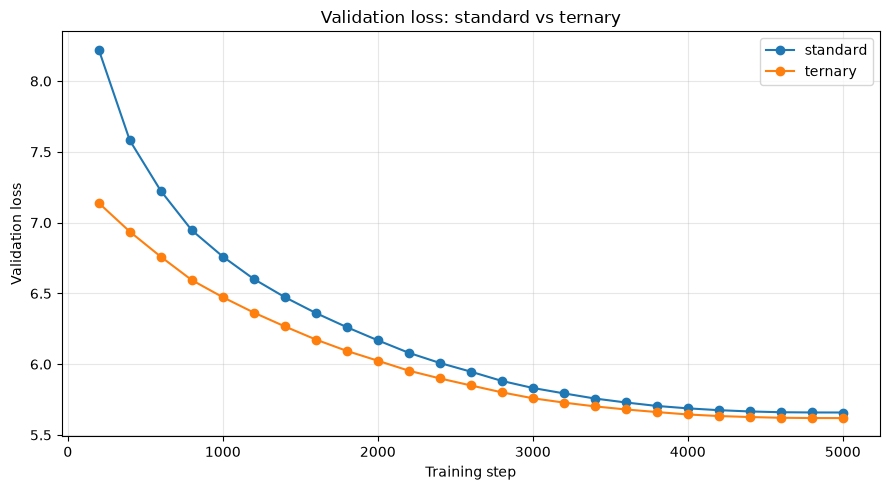

In [19]:
history = pd.concat(
    [standard_history, ternary_history],
    ignore_index=True,
)
history.to_csv(Path(cfg.output_dir) / "training_history.csv", index=False)
display(history)

fig, ax = plt.subplots(figsize=(9, 5))
for model_name, group in history.groupby("model"):
    ax.plot(group["step"], group["val_loss"], marker="o", label=model_name)
ax.set_xlabel("Training step")
ax.set_ylabel("Validation loss")
ax.set_title("Validation loss: standard vs ternary")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
quality_comparison = pd.DataFrame(
    [standard_metrics, ternary_metrics]
)[
    [
        "model",
        "val_loss",
        "perplexity",
        "token_accuracy",
        "training_seconds",
        "overall_train_tokens_per_second",
        "training_steps",
    ]
].sort_values("val_loss")

display(quality_comparison)
quality_comparison.to_csv(
    Path(cfg.output_dir) / "quality_comparison.csv",
    index=False,
)

,model,val_loss,perplexity,token_accuracy,training_seconds,overall_train_tokens_per_second,training_steps
1,ternary,5.619301,275.696608,0.202702,264.555851,58059.573873,5000
0,standard,5.658730,286.784078,0.202686,274.860680,55882.856625,5000


## 13. Честный forward-бенчмарк

- модели переводятся в `eval()`;
- выполняется прогрев;
- перед началом и после каждого измеряемого блока вызывается `torch.cuda.synchronize()`;
- AMP-настройка одинакова;
- входной батч одинаков;
- измеряется latency и throughput в токенах/с.

In [21]:
def synchronize_device() -> None:
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


@torch.inference_mode()
def benchmark_forward(
    model: nn.Module,
    input_ids: torch.Tensor,
    model_name: str,
) -> dict[str, float]:
    model.eval()
    input_ids = input_ids.to(device)

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    for _ in range(cfg.benchmark_warmup):
        with autocast_context():
            _ = model(input_ids)
    synchronize_device()

    timings_ms = []
    for _ in range(cfg.benchmark_repeats):
        synchronize_device()
        started = time.perf_counter()
        with autocast_context():
            _ = model(input_ids)
        synchronize_device()
        timings_ms.append((time.perf_counter() - started) * 1_000.0)

    mean_ms = statistics.mean(timings_ms)
    median_ms = statistics.median(timings_ms)
    p95_ms = float(np.percentile(timings_ms, 95))
    tokens_per_batch = input_ids.numel()

    result = {
        "model": model_name,
        "device": str(device),
        "batch_size": input_ids.size(0),
        "sequence_length": input_ids.size(1),
        "mean_latency_ms": mean_ms,
        "median_latency_ms": median_ms,
        "p95_latency_ms": p95_ms,
        "tokens_per_second": tokens_per_batch / (mean_ms / 1_000.0),
    }

    if device.type == "cuda":
        result["peak_cuda_memory_mb"] = (
            torch.cuda.max_memory_allocated() / 1024**2
        )
    else:
        result["peak_cuda_memory_mb"] = float("nan")

    return result


_, benchmark_loader = make_dataloaders(cfg.seed)
benchmark_batch = next(iter(benchmark_loader))["input_ids"]

forward_results = pd.DataFrame(
    [
        benchmark_forward(standard_model, benchmark_batch, "standard"),
        benchmark_forward(ternary_model, benchmark_batch, "ternary"),
    ]
)

display(forward_results)
forward_results.to_csv(
    Path(cfg.output_dir) / "forward_benchmark.csv",
    index=False,
)

,model,device,batch_size,sequence_length,mean_latency_ms,median_latency_ms,p95_latency_ms,tokens_per_second,peak_cuda_memory_mb
0,standard,cuda,4,384,4.022454,3.854460,4.292354,381856.456417,728.453125
1,ternary,cuda,4,384,6.261687,6.103747,6.846398,245301.296779,728.453125


## 14. Параметры и размер модели

`actual_state_dict_mb` — реальный размер тензоров текущего `state_dict` в памяти. Для QAT-модели он остаётся полноточным.

`estimated_packed_mb` — оценка deployment-представления, в котором:

- веса `TernaryLinear` занимают 2 бита на элемент;
- один scale на выходной канал хранится в FP16;
- остальные уникальные параметры хранятся в FP16.

Это оценка хранения, а не готовый быстрый inference-формат.

In [22]:
def unique_parameters(model: nn.Module):
    seen = set()
    for name, parameter in model.named_parameters():
        pointer = parameter.untyped_storage().data_ptr()
        if pointer in seen:
            continue
        seen.add(pointer)
        yield name, parameter


def actual_parameter_bytes(model: nn.Module) -> int:
    return sum(
        parameter.numel() * parameter.element_size()
        for _, parameter in unique_parameters(model)
    )


def estimate_packed_ternary_bytes(model: nn.Module) -> int:
    ternary_weight_ids = {
        id(module.weight)
        for module in model.modules()
        if isinstance(module, TernaryLinear)
    }

    ternary_weight_count = 0
    scale_count = 0
    other_parameter_count = 0
    seen = set()

    for module in model.modules():
        if isinstance(module, TernaryLinear):
            scale_count += module.out_features

    for _, parameter in unique_parameters(model):
        parameter_id = id(parameter)
        if parameter_id in seen:
            continue
        seen.add(parameter_id)

        if parameter_id in ternary_weight_ids:
            ternary_weight_count += parameter.numel()
        else:
            other_parameter_count += parameter.numel()

    ternary_bytes = math.ceil(ternary_weight_count * 2 / 8)
    scale_bytes = scale_count * 2  # FP16
    other_bytes = other_parameter_count * 2  # FP16
    return ternary_bytes + scale_bytes + other_bytes


def model_size_row(model: nn.Module, name: str) -> dict[str, float]:
    actual_bytes = actual_parameter_bytes(model)
    packed_bytes = (
        estimate_packed_ternary_bytes(model)
        if name == "ternary"
        else actual_bytes / 2  # возможный FP16 export стандартной модели
    )
    return {
        "model": name,
        "unique_parameters": sum(p.numel() for _, p in unique_parameters(model)),
        "actual_state_dict_mb": actual_bytes / 1024**2,
        "estimated_export_mb": packed_bytes / 1024**2,
    }


size_comparison = pd.DataFrame(
    [
        model_size_row(standard_model, "standard"),
        model_size_row(ternary_model, "ternary"),
    ]
)
display(size_comparison)
size_comparison.to_csv(
    Path(cfg.output_dir) / "model_size_comparison.csv",
    index=False,
)

,model,unique_parameters,actual_state_dict_mb,estimated_export_mb
0,standard,22442496,85.611328,42.805664
1,ternary,22442496,85.611328,27.108398


In [23]:
final_ternary_stats = ternary_code_statistics(ternary_model)
display(final_ternary_stats)
final_ternary_stats.to_csv(
    Path(cfg.output_dir) / "ternary_code_statistics.csv",
    index=False,
)

,layer,weights,-1_%,0_%,+1_%
0,blocks.0.attn.q_proj,65536,34.663391,30.647278,34.689331
1,blocks.0.attn.k_proj,65536,34.675598,30.546570,34.777832
2,blocks.0.attn.v_proj,65536,34.007263,31.893921,34.098816
3,blocks.0.attn.out_proj,65536,34.220886,31.727600,34.051514
4,blocks.0.ffn.0,262144,34.493256,30.824661,34.682083
...,...,...,...,...,...
67,blocks.11.attn.k_proj,65536,34.716797,30.342102,34.941101
68,blocks.11.attn.v_proj,65536,34.848022,30.662537,34.489441
69,blocks.11.attn.out_proj,65536,34.246826,31.204224,34.548950
70,blocks.11.ffn.0,262144,34.607315,30.666351,34.726334


## 15. Генерация текста

Для короткого эксперимента результат может быть слабым у обеих моделей. Генерация предназначена только для качественной проверки, а не вместо validation loss/perplexity.

In [30]:
@torch.inference_mode()
def generate_text(
    model: nn.Module,
    prompt: str,
    max_new_tokens: int = 80,
    temperature: float = 0.8,
    top_k: Optional[int] = 50,
) -> str:
    if temperature <= 0:
        raise ValueError("temperature должна быть больше нуля")

    model.eval()
    encoded = tokenizer(
        prompt,
        add_special_tokens=False,
        return_tensors="pt",
    )["input_ids"].to(device)

    if encoded.size(1) == 0:
        encoded = torch.tensor(
            [[tokenizer.eos_token_id]],
            dtype=torch.long,
            device=device,
        )

    generated = encoded

    for _ in range(max_new_tokens):
        model_input = generated[:, -cfg.sequence_length:]
        with autocast_context():
            logits = model(model_input)[:, -1, :].float()

        logits = logits / temperature
        if top_k is not None:
            k = min(top_k, logits.size(-1))
            threshold = torch.topk(logits, k=k, dim=-1).values[:, -1:]
            logits = logits.masked_fill(logits < threshold, float("-inf"))

        probabilities = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probabilities, num_samples=1)
        generated = torch.cat([generated, next_token], dim=1)

        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated[0].tolist(), skip_special_tokens=True)


prompt = "Вопрос:\nЧто такое машинное обучение?\n\nОтвет:\n"

prompt = "Привет как дела?"

In [32]:
seed_everything(cfg.seed)
print("STANDARD:\n", generate_text(standard_model, prompt))

STANDARD:
 Привет как дела?

Ответ:
Ивиширу и "не" и "Кр" и "И" и "ИТ-Эй",".

У меня он "Уми", "уэгу"

# Шаг 2: В "Фью", "И "Б"

Введите "Мы уже было "ко""


In [31]:
seed_everything(cfg.seed)
print("\nTERNARY:\n", generate_text(ternary_model, prompt))


TERNARY:
 Привет как дела?

####### Шаг 4: Определение и каждый день:

- **Оключите для вашего анализа данных, которые могут быть для каждой сети.

###### Шаг 4.

- Шаг 2. **Обложите все метод, то время:
- и т.
- **Выказать


## 16. Объединённое резюме эксперимента

In [27]:
summary = (
    quality_comparison
    .merge(forward_results, on="model", how="left")
    .merge(size_comparison, on="model", how="left")
)

display(summary)
summary.to_csv(Path(cfg.output_dir) / "experiment_summary.csv", index=False)

print(f"Все результаты сохранены в: {Path(cfg.output_dir).resolve()}")

,model,val_loss,perplexity,token_accuracy,training_seconds,overall_train_tokens_per_second,training_steps,device,batch_size,sequence_length,mean_latency_ms,median_latency_ms,p95_latency_ms,tokens_per_second,peak_cuda_memory_mb,unique_parameters,actual_state_dict_mb,estimated_export_mb
0,ternary,5.619301,275.696608,0.202702,264.555851,58059.573873,5000,cuda,4,384,6.261687,6.103747,6.846398,245301.296779,728.453125,22442496,85.611328,27.108398
1,standard,5.658730,286.784078,0.202686,274.860680,55882.856625,5000,cuda,4,384,4.022454,3.854460,4.292354,381856.456417,728.453125,22442496,85.611328,42.805664


Все результаты сохранены в: /home/phil/GitHub/llm/transformer_benchmark_outputs


## Как интерпретировать результат

1. **Качество** сравнивайте прежде всего по `val_loss` и `perplexity` после одинакового числа шагов и токенов.
2. **Скорость QAT** не равна скорости packed ternary inference. `TernaryLinear` каждый forward квантует FP32-веса и вызывает обычный `F.linear`, поэтому без специализированного kernel тернарная модель часто медленнее.
3. **Фактическая память обучения** остаётся близкой к FP32: хранятся мастер-веса, градиенты и состояния AdamW.
4. **Оценка packed size** показывает только потенциальный размер экспортированных тернарных весов.
5. При большом словаре основную часть параметров могут занимать embedding/LM-head. Если они остаются полноточными, общий коэффициент сжатия ограничен.
6. Для устойчивого вывода повторите эксперимент с несколькими seed и сравните среднее и стандартное отклонение метрик.